## Analyse der Eingangsdaten
Von 3 verschiedenen Datensätzen bestimmen wir uns die Features je Datensatz.
Desweiteren analysieren wir die Datentypen und untersuchen auf Unbekannte Werte.

Funktion um pandas Dataframe zu erzeugen und die Informationen in einer Exceldatei zu speichern

In [11]:
import pandas as pd

def process_files_to_excel(files, drop_target=False):
    
    dfs = {}

    for name, path in files.items():
        
        # 1. DataFrame erstellen
        df = pd.read_csv(path)
                
        # 2. DataFrame im Dictionary speichern (Name = Key)
        dfs[name] = df
        
        # 3. Describe berechnen
        desc = df.describe().T
        
        # 4. Excel-Datei pro Dataset schreiben
        output_file = f"{name}.xlsx"
        desc.to_excel(output_file)

    return dfs

Funktion aufrufen und alle 3 Datensätze übergeben

In [12]:
files = {
    "df_full_012": "Original/diabetes_012_health_indicators_BRFSS2015.csv",
    "df_full_01": "Original/diabetes_binary_health_indicators_BRFSS2015.csv",
    "df_5050_01": "Original/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
}

dfs = process_files_to_excel(files, drop_target=True)
df_full_012 = dfs["df_full_012"]
df_full_01 = dfs["df_full_01"]
df_5050_01 = dfs["df_5050_01"]

In [13]:
print(df_full_012.columns)

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')


In [14]:
print(df_5050_01.columns)

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')


In [15]:
print(df_full_01.columns)

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')


Die Features von allen 3 Datensätzen sind gleich mit Ausnahme der Zielspalte.

| Variable             | Beschreibung |
|----------------------|-------------|
| HighBP               | 0 = no high BP<br>1 = high BP |
| HighChol             | 0 = no high cholesterol<br>1 = high cholesterol |
| CholCheck            | 0 = no cholesterol check in 5 years<br>1 = yes cholesterol check in 5 years |
| BMI                  | Body Mass Index |
| Smoker               | Have you smoked at least 100 cigarettes in your entire life? [5 packs = 100 cigarettes]<br>0 = no<br>1 = yes |
| Stroke               | (Ever told) you had a stroke.<br>0 = no<br>1 = yes |
| HeartDiseaseorAttack | Coronary heart disease (CHD) or myocardial infarction (MI)<br>0 = no 1 = yes |
| PhysActivity         | Physical activity in past 30 days (not including job)<br>0 = no<br>1 = yes |
| Fruits               | Consume fruit 1 or more times per day<br>0 = no<br>1 = yes |
| Veggies              | Consume vegetables 1 or more times per day<br>0 = no<br>1 = yes |
| HvyAlcoholConsump    | Heavy drinkers (men >14 drinks/week, women >7 drinks/week)<br>0 = no<br>1 = yes |
| AnyHealthcare        | Have any kind of health care coverage<br>0 = no<br>1 = yes |
| NoDocbcCost          | Needed to see a doctor in past 12 months but could not because of cost<br>0 = no<br>1 = yes |
| GenHlth              | General health (1–5)<br>1 = excellent<br>2 = very good<br>3 = good<br>4 = fair<br>5 = poor |
| MentHlth             | Days in past 30 days mental health not good (1–30 days) |
| PhysHlth             | Days in past 30 days physical health not good (1–30 days) |
| DiffWalk             | Serious difficulty walking or climbing stairs<br>0 = no<br>1 = yes |
| Sex                  | 0 = female<br>1 = male |
| Age                  | 13-level age category (1 = 18–24, 9 = 60–64, 13 = 80+) |
| Education            | Education level (1–6)<br>1 = never attended school/kindergarten<br>2 = grades 1–8<br>3 = grades 9–11<br>4 = high school graduate<br>5 = some college/technical school<br>6 = college graduate |
| Income               | Income scale (1–8)<br>1 = < $10,000<br>5 = < $35,000<br>8 = ≥ $75,000 |

## Datenbeschreibung .describe()

In [16]:
df_full_012.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [17]:
df_5050_01.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,...,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,0.500000,0.563458,0.525703,0.975259,29.856985,0.475273,0.062171,0.147810,0.703036,0.611795,...,0.954960,0.093914,2.837082,3.752037,5.810417,0.252730,0.456997,8.584055,4.920953,5.698311
std,0.500004,0.495960,0.499342,0.155336,7.113954,0.499392,0.241468,0.354914,0.456924,0.487345,...,0.207394,0.291712,1.113565,8.155627,10.062261,0.434581,0.498151,2.852153,1.029081,2.175196
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,0.500000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [18]:
df_full_01.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


## Prüfen b es fehlende Werte bei den Features gibt:

In [19]:
for name, df in dfs.items():
    missing = df.isnull().sum().sum()
    print(f"{name}: {missing} fehlende Werte")

df_full_012: 0 fehlende Werte
df_full_01: 0 fehlende Werte
df_5050_01: 0 fehlende Werte


In [ ]:
Keine fehlenden Werte enthalten.

## Prüfen der Datentypen

In [20]:
for name, df in dfs.items():
    datentypen = df.info()
    print(f"{name}: {datentypen} fehlende Werte")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

## Histogramme

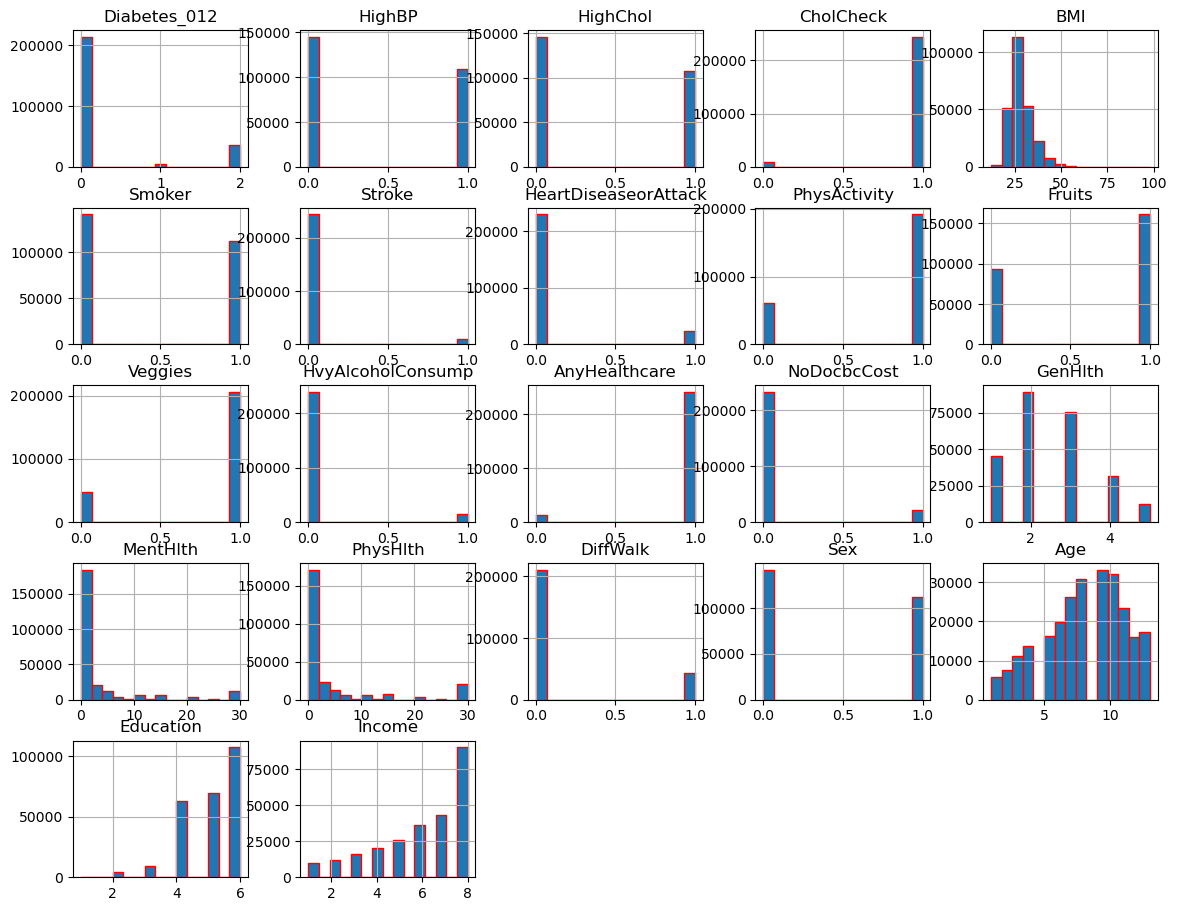

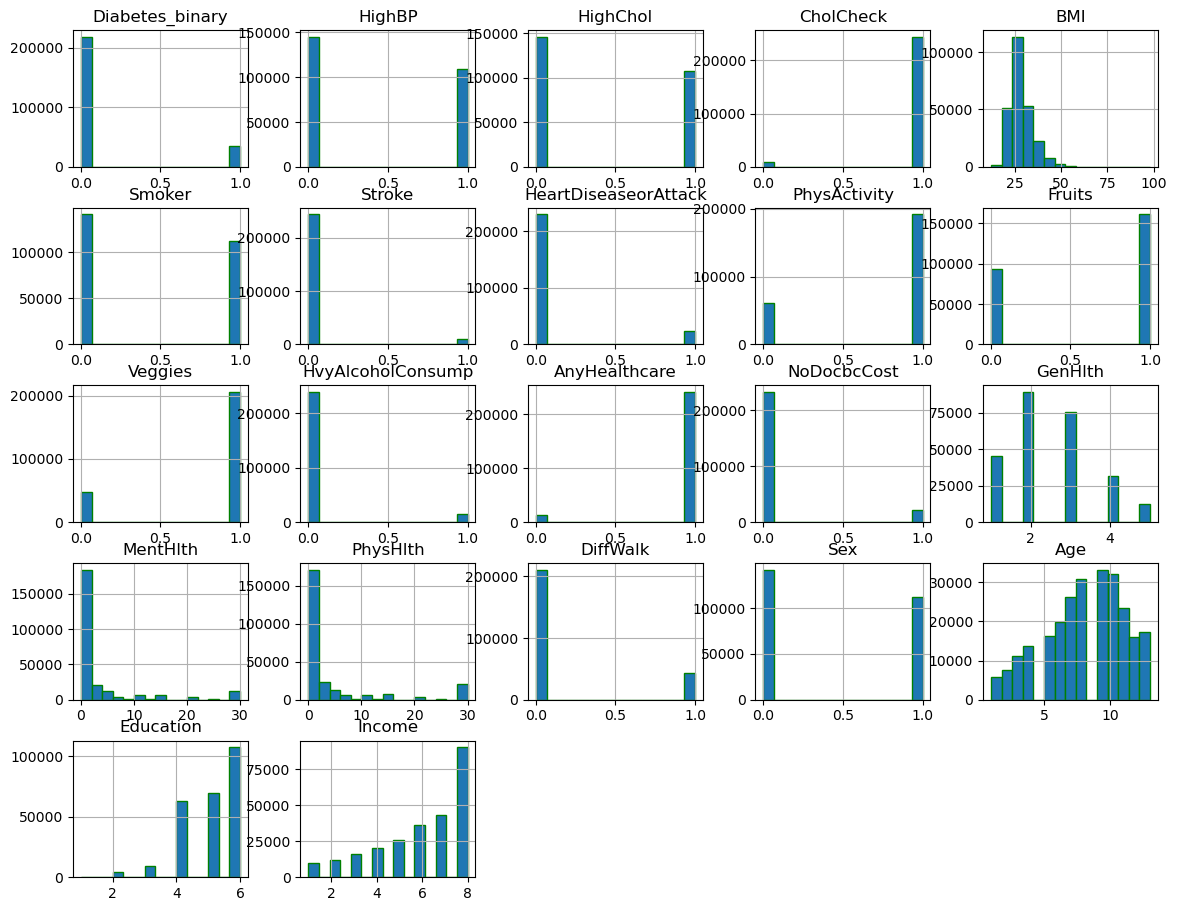

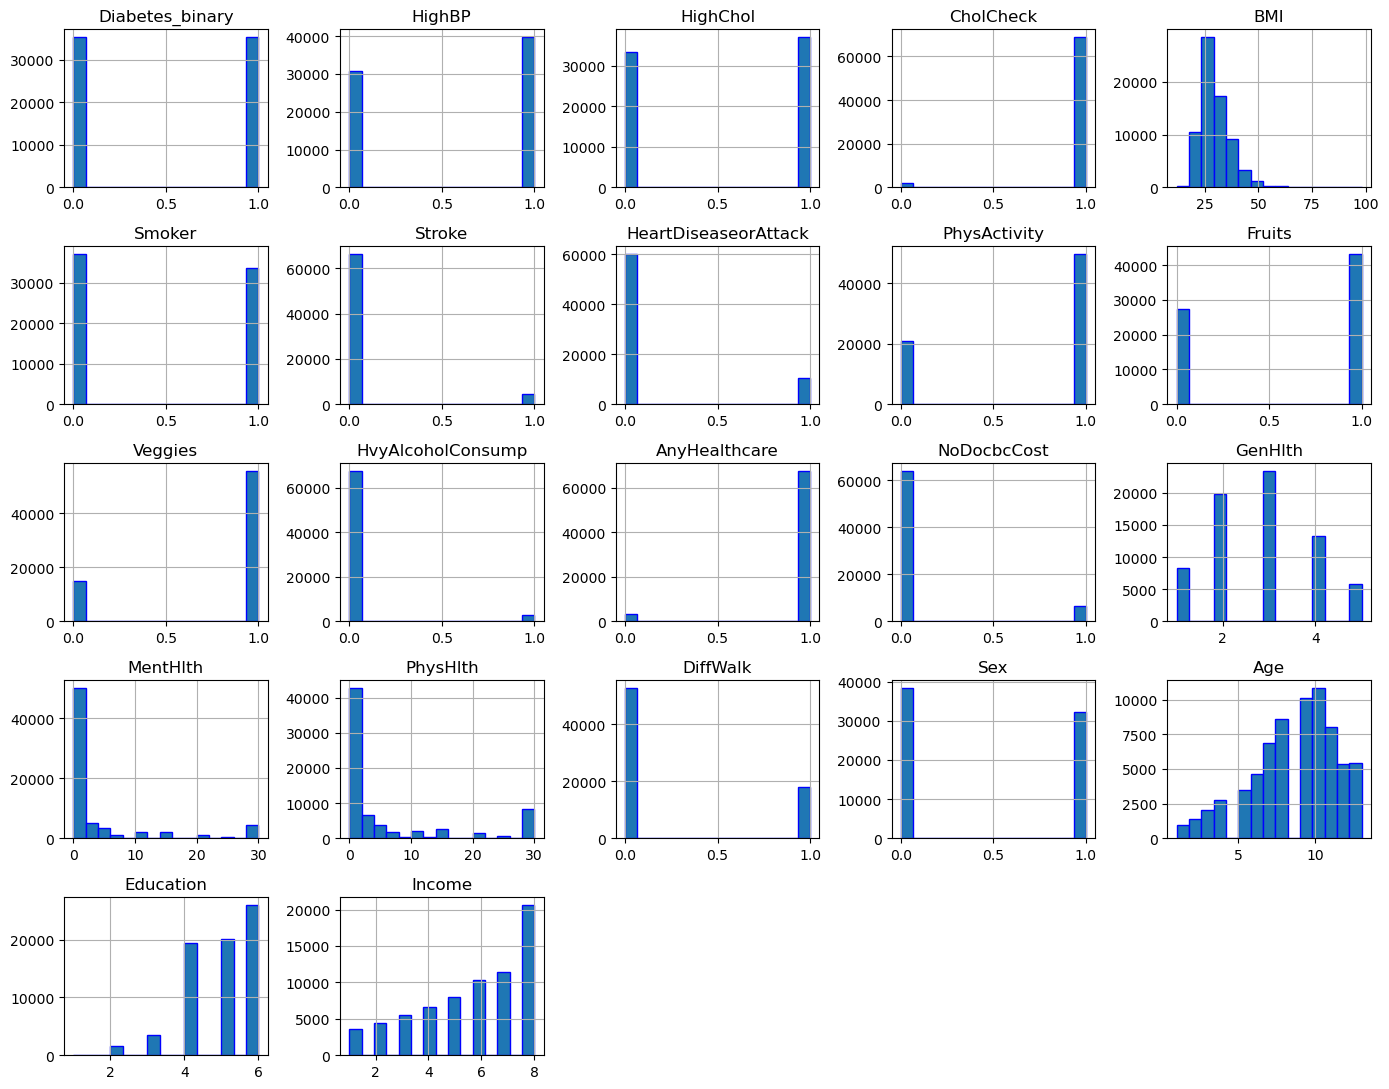

In [54]:
import matplotlib.pyplot as plt
df_full_012.hist(bins=15, figsize=(14, 11), edgecolor="red")
df_full_01.hist(bins=15, figsize=(14, 11), edgecolor="green")
df_5050_01.hist(bins=15, figsize=(14, 11), edgecolor="blue")
plt.tight_layout()
plt.show()

Wir entscheiden uns für die weitere Arbeit, den Dataframe: df_5050_01
Grund: Wir möchten die Kranken vorraussagen. Wenn ein Algorithmus zuviele von einer Sorte hätte, dann würde derAlgo zu diesem Typ tendieren.
In den Datensätzen df_full_01 und df_full_012 liegt ein ungleichgewicht vor. Daher haben wir uns für df_5050_01 entschieden. 

Teilen des Datensatz df_5050_01 in Diabetiker und Nicht Diabetiker. Visualisieren der Features in Abhängigkeit des Targets.

In [60]:
df_5050_01_diabetiker = df_5050_01[df_5050_01['Diabetes_binary'] == 1]
df_5050_01_nicht_diabetiker = df_5050_01[df_5050_01['Diabetes_binary'] == 0]

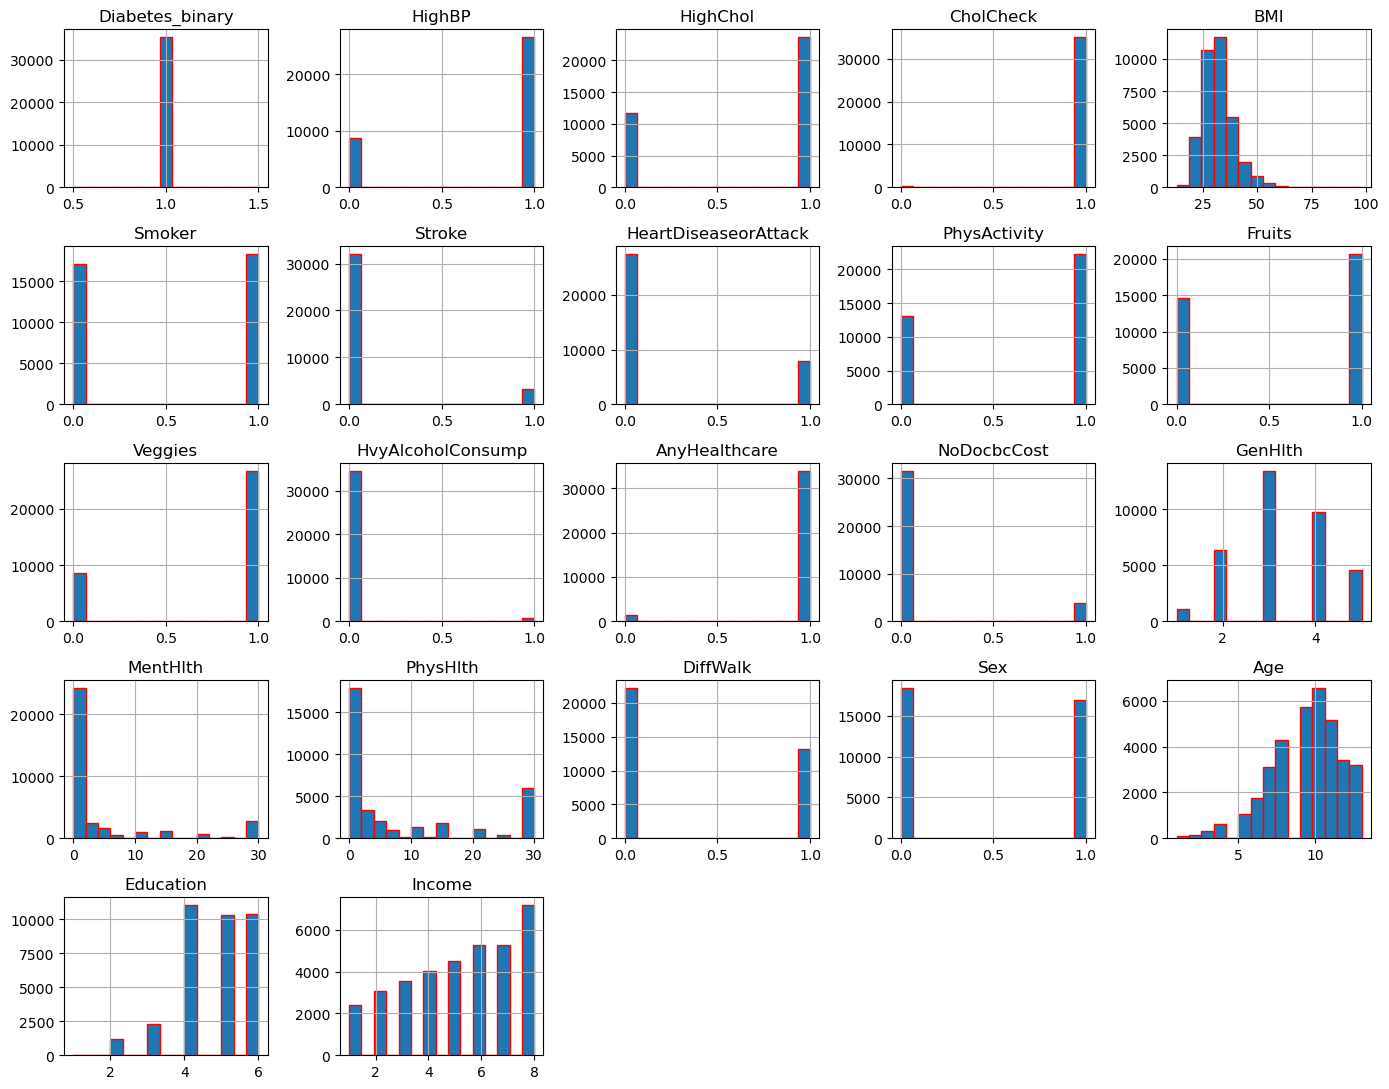

In [61]:
df_5050_01_diabetiker.hist(bins=15, figsize=(14, 11), edgecolor="red")
#df_5050_01_nicht_diabetiker.hist(bins=15, figsize=(14, 11), edgecolor="green")
plt.tight_layout()
plt.show()

In [ ]:
Diabetiker haben hoche HighBP und hoche HighChol.
Rauchen ist ungefähr gleich verteil. Scheint keinen großen einfluß zu haben.
    
CholCheck ist uninteressant